# Домашнее задание
## Работа с Pandas

In [2]:
import pandas as pd
# перед импортом необходимо установить библиотеку в терминале при помощи команды pip install pandas

_Задание 1: Создание DataFrame_

Цель: Научиться создавать DataFrame из различных источников данных.

Создайте DataFrame из словаря data.

Теория: DataFrame — это двумерная структура данных в Pandas, похожая на таблицу с метками строк и столбцов. Его можно создать, передав Python-объекты, такие как словари, списки и т.д. Обозначается как df = pd.DataFrame({словарь})

Добавьте столбец Salary с зарплатами.

Подсказка: Используйте синтаксис: df['new_column'] = значения.

In [3]:
data = {
    'Name': ['Anna', 'Ivan', 'Sergey'],
    'Age': [23, 30, 25],
    'City': ['Moscow', 'Kazan', 'Samara']
}

In [18]:
import pandas as pd
data = {
    'Name': ['Anna', 'Ivan', 'Sergey'],
    'Age': [23, 30, 25],
    'City': ['Moscow', 'Kazan', 'Samara']
}
df = pd.DataFrame(data)
df['Salary']=[1000,2000,3000]
print(df)

     Name  Age    City  Salary
0    Anna   23  Moscow    1000
1    Ivan   30   Kazan    2000
2  Sergey   25  Samara    3000


_Задание 2: Импорт данных из CSV_

Цель: Научиться импортировать данные из файла.

Загрузите данные из файла data.csv с помощью функции pd.read_csv(). Файл приложен к заданию в Classroom.

Теория: Pandas позволяет загружать данные из различных форматов, включая CSV, Excel, SQL и другие. pd.read_csv("название файла") — одна из самых популярных функций для загрузки данных из текстовых файлов.

Если файл с данными сохранен в ту же папку, что и файл ipynb, то будет достаточно передать только название файла и его разрешение ("data.csv"), если нет - передать полный путь к файлу

Выведите первые 5 строк таблицы с помощью метода head().

Подсказка: Метод head() отображает первые несколько строк DataFrame, что полезно для быстрого просмотра данных.

In [34]:
import pandas as pd
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\data.csv')
print(df.head(5))

      Name  Age    City  Salary
0     Anna   23  Moscow   50000
1     Ivan   30   Kazan   60000
2   Sergey   25  Samara   55000
3     Olga   22  Moscow   48000
4  Nikolay   35   Kazan   70000


_Задание 3: Основные операции с DataFrame_

Цель: Научиться фильтровать данные и применять простые операции.

1. В датафрейме, импортированном из csv во втором задании, отфильтруйте строки, где возраст больше 25 лет.

Теория: Фильтрация в Pandas основана на логических выражениях. Можно использовать условия вида df['Age'] > 25, чтобы получить булев массив и применить его для фильтрации данных. Передача этого булевого массива в df[ ] отфильтровывает DataFrame, возвращая только строки, где условие равно True.

2. Посчитайте среднюю зарплату с помощью метода mean().

Подсказка: Для доступа к столбцам используйте df['column_name'], а для выполнения агрегирующих операций — методы, такие как mean(), sum(), count() и т.д.

In [50]:
import pandas as pd
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\data.csv')
df_age = df['Age']>25
print(df[df_age])
print(f"Средняя зарплата = {df['Salary'].mean().round(2)}")

      Name  Age    City  Salary
1     Ivan   30   Kazan   60000
4  Nikolay   35   Kazan   70000
5     Oleg   38  Moscow   90000
Средняя зарплата = 62166.67


_Задание 4: Работа с пропущенными данными_

Цель: Научиться находить и обрабатывать пропущенные данные.

Загрузите данные из файла employees.csv. Используйте метод isnull(), чтобы найти пропущенные значения в столбцах. Данный массив можно использовать для различных целей:

- df.isnull().sum() подсчитает количество пропущенных значений в каждом столбце
- df.isnull().any(axis=1) отфильтрует строки, где есть хотя бы одно пропущенное значение. Здесь any(axis=1) проверяет наличие пропусков по строкам


Теория: В реальных данных часто встречаются пропущенные значения. Pandas предоставляет методы isnull() и notnull() для их поиска, а также fillna() и dropna() для их обработки.
- df.dropna() удалит все строки, содержащие хотя бы одно пропущенное значение
- fillna() заполнит пропущенные значения значением, указанным в скобках (например, средним значением зарплаты)

Замените пропущенные значения в столбце Salary на среднее значение этого столбца.

Подсказка: Используйте метод fillna() для замены значений.

In [72]:
import pandas as pd
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\employees.csv')
print(df.isnull().sum())
print(df.isnull().any(axis=1))
print(df.dropna())
print(df['Salary'].fillna(df['Salary'].mean()).reset_index())

Name      0
Age       1
City      1
Salary    1
dtype: int64
0    False
1     True
2     True
3    False
4    False
dtype: bool
      Name   Age    City   Salary
0     Anna  23.0  Moscow  50000.0
3     Olga  22.0  Moscow  48000.0
4  Nikolay  35.0   Kazan  70000.0
   index   Salary
0      0  50000.0
1      1  60000.0
2      2  57000.0
3      3  48000.0
4      4  70000.0


_Задание 5: Группировка данных_

Цель: Научиться группировать данные и применять агрегирующие функции.

Используйте метод groupby(), чтобы сгруппировать данные по столбцу City и посчитать среднюю зарплату для каждого города. Для задания используйте первый датафрейм, импортированный из файла data.csv

Теория: groupby() — мощный инструмент для группировки данных по одному или нескольким признакам с последующим применением агрегирующих функций, таких как mean(), sum(), count() и т.д.

Выведите результаты в виде нового DataFrame.

In [98]:
import pandas as pd
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\data.csv')
df_city = df.groupby('City')['Salary'].mean().round(2).reset_index()
df_city.rename(columns={'Salary':'Avr.Salary'},inplace=True)
print(df_city)                     

     City  Avr.Salary
0   Kazan    65000.00
1  Moscow    62666.67
2  Samara    55000.00


_Задание 6: Объединение данных_

Цель: Научиться объединять DataFrame с помощью методов merge() и concat().

1. У вас есть два DataFrame: df1 и df2. Объедините их по столбцу ID с помощью merge(). Синтаксис выглядит как левый_датафрейм.merge(правый_датафрейм)

Теория: merge() — это метод, который используется для объединения двух DataFrame по общим столбцам. Он аналогичен SQL операциям JOIN.

2. Объедините несколько DataFrame вдоль строк с помощью concat(). Синтаксис выглядит как pf.concat([датафрейм1, датафрейм2], axis=1). axis=1 объединяет по строкам, axis=0 (по умолчанию) объединяет по столбцам. Решите задание с обоими вариантами axis и посмотрите на результат

Подсказка: concat() позволяет объединять DataFrame по строкам или столбцам, в зависимости от параметра axis.

In [106]:
df1 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Name': ['Anna', 'Ivan', 'Sergey']
})

df2 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Salary': [1000, 1500, 1200]
})
print(df1.merge(df2))
print(pd.concat([df1,df2],axis=1))
print(pd.concat([df1,df2],axis=0))

   ID    Name  Salary
0   1    Anna    1000
1   2    Ivan    1500
2   3  Sergey    1200
   ID    Name  ID  Salary
0   1    Anna   1    1000
1   2    Ivan   2    1500
2   3  Sergey   3    1200
   ID    Name  Salary
0   1    Anna     NaN
1   2    Ivan     NaN
2   3  Sergey     NaN
0   1     NaN  1000.0
1   2     NaN  1500.0
2   3     NaN  1200.0


_Задание 7: Визуализация данных с Pandas_

Цель: Научиться строить простые графики.

1. Постройте гистограмму распределения зарплат с помощью метода plot(). Используйте первый датафрейм, импортированный из файла data.csv

Синтаксис: df['заголовок_столбца'].plot(). Для создания гистограммы в plot() нужно передать параметр kind='hist'. Также можно опционально указывать через запятую параметры bins=число (количество столбцов (корзин) для распределения данных), edgecolor='black' или любой другой цвет для создания черной границы столбцов, а также многие другие, указанные в документации.

Теория: Pandas имеет встроенную функциональность для построения простых графиков. Используйте метод plot(), который взаимодействует с библиотекой Matplotlib (ее тоже нужно установить командой pip install matplotlib и импортировать для использования) для создания графиков, таких как гистограммы, линейные графики и т.д.

2. Постройте круговую диаграмму, показывающую распределение сотрудников по городам.

Для создания диаграммы нужно подготовить датафрейм, содержащий группировку данных по городам и подсчет количества сотрудника в каждом 

Синтаксис: df['столбец'].value_counts()

Подсказка: Используйте plot(kind='pie').

Также можно дополнительно передавать различные параметры, например:
- Параметр autopct='%1.1f%%' показывает процент каждого сегмента.
- startangle=90 поворачивает круг, чтобы начать диаграмму с верхней части.
- colors=['skyblue', 'lightgreen', 'orange'] перекрасит диаграмму в нужные цвета

Axes(0.125,0.11;0.775x0.77)


Text(0, 0.5, 'Частота')

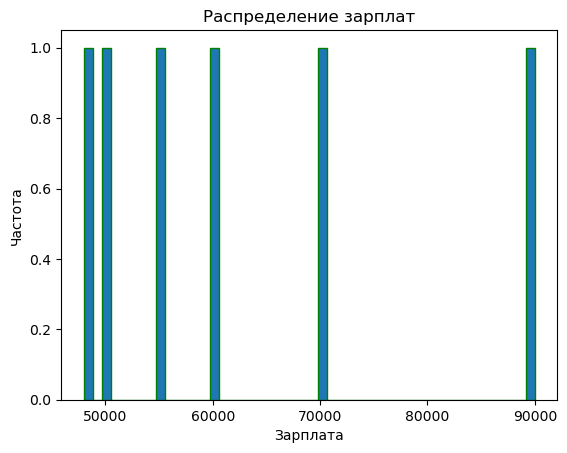

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\data.csv')
print(df['Salary'].plot(kind='hist', bins=50, edgecolor='green'))
plt.title('Распределение зарплат')
plt.xlabel('Зарплата')
plt.ylabel('Частота')


Axes(0.22375,0.11;0.5775x0.77)


(-1.1, 1.1, -1.1, 1.1)

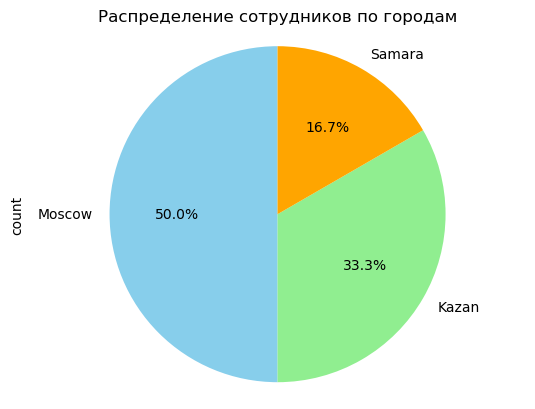

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\data.csv')
df_city=df['City'].value_counts()
print(df_city.plot(kind='pie',autopct='%1.1f%%',colors=['skyblue', 'lightgreen', 'orange'], startangle=90))
plt.title('Распределение сотрудников по городам')
plt.axis('equal')


_Задание 8: Продвинутая фильтрация_

Цель: Научиться комбинировать условия для фильтрации данных.

1. Отфильтруйте строки, где возраст больше 25 и зарплата больше 60000. Используйте первый датафрейм, импортированный из файла data.csv

Теория: В Pandas можно объединять условия с помощью логических операторов, таких как & (и) и | (или). Например, для фильтрации по двум условиям могло бы использоваться выражение вида: (df['Age'] > 40) | (df['Salary'] > 1200). 

2. Выведите только столбцы Name и City для отфильтрованных данных.

Подсказка: Используйте df[['Name', 'City']] для выбора нескольких столбцов.



In [230]:
import pandas as pd
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\data.csv')
df_filt= (df['Age'] > 25) & (df['Salary'] > 60000)
print(df[df_filt])
print(df[df_filt][['Name', 'City']])

      Name  Age    City  Salary
4  Nikolay   35   Kazan   70000
5     Oleg   38  Moscow   90000
      Name    City
4  Nikolay   Kazan
5     Oleg  Moscow
